# Exercício:

## 01 – Importe o .csv utilizado no exercício 1 da aula 13 e instancie um objeto da classe DataFrame. Busque no GenBank do NCBI, a sequência aminoacídica referente à cada gene, baixe o arquivo FASTA, e importe para o Python. Instancie um objeto da classe DataFrame onde as linhas serão os genes e as colunas, a sigla, o código de referência e a sequência aminoacídica.

In [2]:
import pandas as pd
import numpy as np
from Bio import Entrez
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_genes = pd.read_csv("genes.csv", index_col="Unnamed: 0")
df_genes.head()

,numero de caracteres,iniciais,qtd_a,se_tem_hu
BRCA1,5,BR,1,False
TP53,4,TP,0,False
EGFR,4,EG,0,False
CHEK2,5,CH,0,False
PTEN,4,PT,0,False


In [4]:
df_genes['id_entrez'] = [
    "NM_005101.4",
    "NM_001419.3",
    "NM_024013.3",
    "NM_001270508.2",
    "NM_004046.6",
]

df_genes['id_protein'] = [
    'NP_005092.1',
    "NP_001410.2",
    "NP_000596.2",
    "NP_001257437.1",
    "NP_004037.1",
]
df_genes

,numero de caracteres,iniciais,qtd_a,se_tem_hu,id_entrez,id_protein
BRCA1,5,BR,1,False,NM_005101.4,NP_005092.1
TP53,4,TP,0,False,NM_001419.3,NP_001410.2
EGFR,4,EG,0,False,NM_024013.3,NP_000596.2
CHEK2,5,CH,0,False,NM_001270508.2,NP_001257437.1
PTEN,4,PT,0,False,NM_004046.6,NP_004037.1


In [5]:
def salvar_fasta_gene(id_protein: str, nome_gene: str) -> None:
    '''
        Salva a sequência de um gene em formato FASTA.
            Args:
                id_protein (str): ID do gene no GenBank.
                nome_gene (str): Nome do gene para salvar o arquivo.
            Returns:
                None
    '''
    # Necessário informar seu email
    Entrez.email = "seu@email.com"

    # Busca a sequência (ex: um ID do GenBank)
    handle = Entrez.efetch(db="protein", id=id_protein, rettype="fasta", retmode="text")
    record = handle.read()
    handle.close()

    # Salva o arquivo
    with open(f"./exercicios/data/{nome_gene}.fasta", "w") as f:
        fasta = f.write(record)
    
    return None

In [6]:
print(salvar_fasta_gene)

<function salvar_fasta_gene at 0x000001F8CE8FB640>


In [7]:
from Bio import Entrez, SeqIO
import pandas as pd

Entrez.email = "nataliazureck.x@gmail.com"

# importar corretamente
df = pd.read_csv('genes.csv', index_col=0)

genes = []
siglas = []
acessos = []
sequencias = []

for gene in df.index:
    try:
        handle = Entrez.esearch(db="protein", term=gene, retmax=1)
        record = Entrez.read(handle)
        handle.close()

        if record["IdList"]:
            seq_id = record["IdList"][0]

            handle = Entrez.efetch(db="protein", id=seq_id,
                                   rettype="fasta", retmode="text")
            seq_record = SeqIO.read(handle, "fasta")
            handle.close()

            genes.append(gene)
            siglas.append(seq_record.name)
            acessos.append(seq_record.id)
            sequencias.append(str(seq_record.seq))

    except:
        print(f"Erro com gene: {gene}")

df_final = pd.DataFrame({
    'gene': genes,
    'sigla': siglas,
    'acesso': acessos,
    'sequencia': sequencias
})

df_final

,gene,sigla,acesso,sequencia
0,BRCA1,WP_481835369.1,WP_481835369.1,MMAELKYGGSALGRTHAKSNGRKVEAYWLGFLEGVLASESIESLEV...
1,TP53,XP_082716714.1,XP_082716714.1,MKTPEAPLLAPDCFPSDRAPAPAPLSPQASPMDKNTDPELMPPTPD...
2,EGFR,XP_082706740.1,XP_082706740.1,MNGHISNHPSGFGMYPSQMNGYGSPPTFSMDREHSSRTSAKALYEQ...
3,CHEK2,XP_082709318.1,XP_082709318.1,MSRETDVECHQPHGSASPQSQGGFSQSHGPSSQPHGSSSQSQGTSS...
4,PTEN,XP_082710137.1,XP_082710137.1,MMFETIPMFSGGTCNPQFVVCQLKVKIYSSNSGPTRREDKFMYFEF...


## 02 – Importe o .csv as informações dos aminoácidos e instancie um objeto da classe DataFrame. Obtenha a frequência absoluta de cada um dos aminoácidos para cada um dos genes. Instancie um objeto da classe DataFrame com as informações.

In [8]:

df = df_final.copy()
aminoacidos = list("ACDEFGHIKLMNPQRSTVWY")
dados = []
for i, row in df.iterrows():
    gene = row['gene']
    seq = row['sequencia']
    
    contagem = {'gene': gene}
    
    for aa in aminoacidos:
        contagem[aa] = seq.count(aa)
    
    dados.append(contagem)
df_freq_aa = pd.DataFrame(dados)

df_freq_aa

,gene,A,C,D,E,F,G,H,I,K,...,M,N,P,Q,R,S,T,V,W,Y
0,BRCA1,27,5,21,25,14,29,7,25,13,...,4,7,5,4,20,25,8,18,4,7
1,TP53,33,15,33,46,22,50,11,15,9,...,8,14,53,21,25,58,27,24,11,14
2,EGFR,56,6,55,48,28,41,20,35,54,...,16,36,65,46,47,76,37,61,9,20
3,CHEK2,27,14,30,45,24,31,13,26,40,...,8,19,28,21,25,57,29,31,7,17
4,PTEN,4,5,18,18,16,6,4,8,19,...,6,13,15,7,5,17,15,13,1,7


In [18]:
df_freq_aa.to_csv('frequencia_aminoacidos.csv', index=False)


## 03 – Qual é o número de Valinas presentes em cada um dos genes? Qual o gene tem o maior número?

In [10]:

df = df_final.copy()
df['Valinas'] = df['sequencia'].apply(lambda x: x.count('V'))
print("Número de Valinas por gene:")
print(df[['gene', 'Valinas']])
gene_max = df.loc[df['Valinas'].idxmax()]

print("\nGene com maior número de Valinas:")
print(gene_max['gene'])
print("Quantidade de Valinas:", gene_max['Valinas'])

Número de Valinas por gene:
    gene  Valinas
0  BRCA1       18
1   TP53       24
2   EGFR       61
3  CHEK2       31
4   PTEN       13

Gene com maior número de Valinas:
EGFR
Quantidade de Valinas: 61


## 04 – Qual a média, a mediana e a moda da frequência absoluta de Serina presente nos genes?

In [11]:
df = df_final.copy()
df['Serina'] = df['sequencia'].str.count('S')
media = df['Serina'].mean()
mediana = df['Serina'].median()
moda = df['Serina'].mode()

print("Média de Serina:", media)
print("Mediana de Serina:", mediana)
print("Moda de Serina:")
print(moda)

Média de Serina: 46.6
Mediana de Serina: 57.0
Moda de Serina:
0    17
1    25
2    57
3    58
4    76
Name: Serina, dtype: int64


## 05 – Gere um histograma, contendo a média e a mediana, com o número de Serinas por gene.

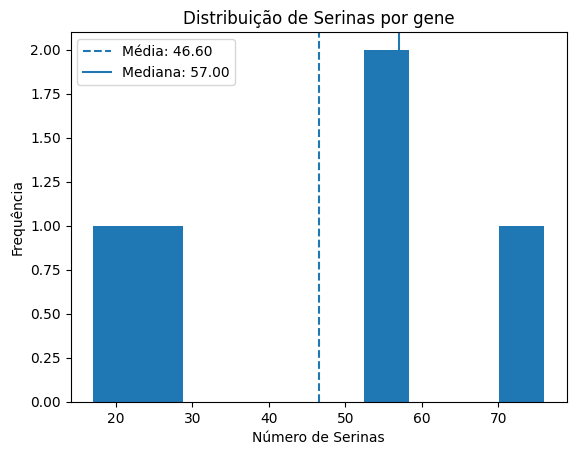

In [12]:
import matplotlib.pyplot as plt
df = df_final.copy()
df['Serina'] = df['sequencia'].str.count('S')
media = df['Serina'].mean()
mediana = df['Serina'].median()
plt.hist(df['Serina'])
plt.axvline(media, linestyle='--', label=f'Média: {media:.2f}')
plt.axvline(mediana, linestyle='-', label=f'Mediana: {mediana:.2f}')
plt.title('Distribuição de Serinas por gene')
plt.xlabel('Número de Serinas')
plt.ylabel('Frequência')
plt.legend()
plt.show()

## 06 – Defina uma função que receba o nome de um aa qualquer e retorne o mesmo resultado do exercício anterior.

0    25
1    58
2    76
3    57
4    17
Name: sequencia, dtype: int64


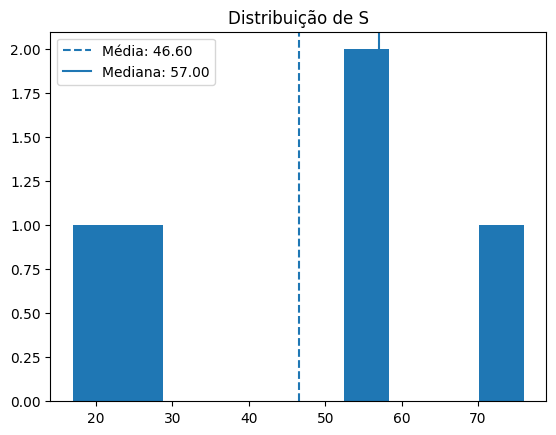

In [13]:
import matplotlib.pyplot as plt
def histograma_aa(df, aa):
    contagem = df['sequencia'].str.count(aa)
    print(contagem.head())  # debug
    media = contagem.mean()
    mediana = contagem.median()
    plt.figure()
    plt.hist(contagem)
    plt.axvline(media, linestyle='--', label=f'Média: {media:.2f}')
    plt.axvline(mediana, linestyle='-', label=f'Mediana: {mediana:.2f}')
    plt.title(f'Distribuição de {aa}')
    plt.legend()
    plt.show()
    
histograma_aa(df_final, 'S')

## 07 – Retorne os gráficos dos aa Glutamina, Glicina, Lisina e Valina. Qual possuí menor diferença entre média e mediana?

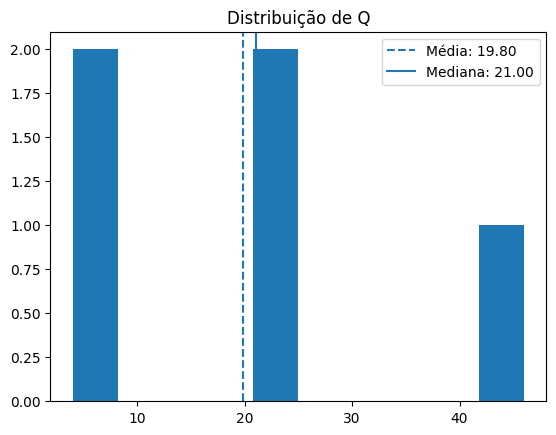

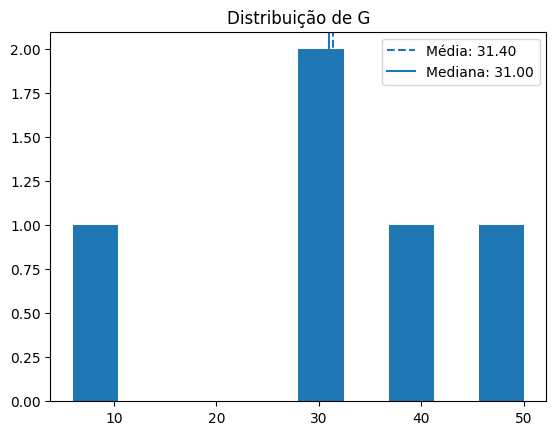

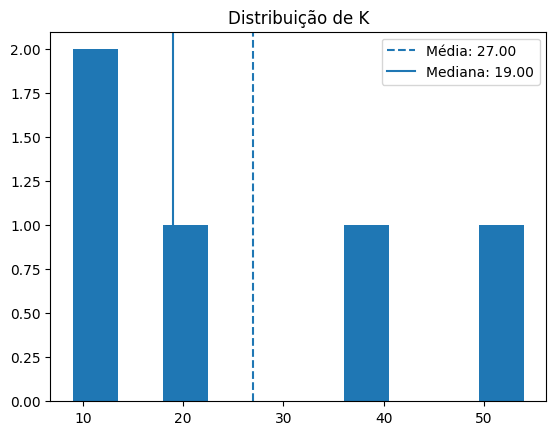

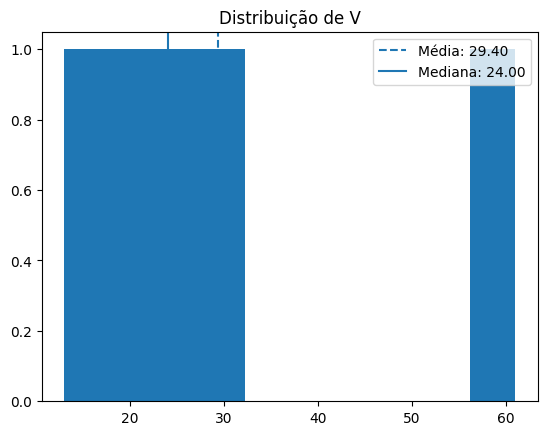

Diferenças: {'Q': np.float64(1.1999999999999993), 'G': np.float64(0.3999999999999986), 'K': np.float64(8.0), 'V': np.float64(5.399999999999999)}
Aminoácido com menor diferença: G


In [14]:
def histograma_aa(df, aa):
    contagem = df['sequencia'].str.count(aa)
    media = contagem.mean()
    mediana = contagem.median()
    
    plt.figure()
    plt.hist(contagem)
    plt.axvline(media, linestyle='--', label=f'Média: {media:.2f}')
    plt.axvline(mediana, linestyle='-', label=f'Mediana: {mediana:.2f}')
    plt.title(f'Distribuição de {aa}')
    plt.legend()
    plt.show()
    
    return media, mediana
resultados = {}
for aa in ['Q', 'G', 'K', 'V']:
    media, mediana = histograma_aa(df_final, aa)
    resultados[aa] = abs(media - mediana)
menor = min(resultados, key=resultados.get)

print("Diferenças:", resultados)
print("Aminoácido com menor diferença:", menor)

## 08 – Dentre os três primeiros genes, qual é a média e a mediana de Cisteína?

In [15]:
df = df_final.copy()
df3 = df.iloc[:3]
df3['Cisteina'] = df3['sequencia'].str.count('C')
media = df3['Cisteina'].mean()
mediana = df3['Cisteina'].median()
print("Cisteína nos 3 primeiros genes:")
print(df3[['gene', 'Cisteina']])
print("\nMédia:", media)
print("Mediana:", mediana)

Cisteína nos 3 primeiros genes:
    gene  Cisteina
0  BRCA1         5
1   TP53        15
2   EGFR         6

Média: 8.666666666666666
Mediana: 6.0


C:\Users\User\AppData\Local\Temp\ipykernel_4604\2167378564.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['Cisteina'] = df3['sequencia'].str.count('C')


## 09 – Analisando o valor médio de aa em cada um dos genes, qual seria o maior gene (maior número médio de aa)?

In [16]:
df = df_final.copy()
df['tamanho'] = df['sequencia'].str.len()
maior_gene = df.loc[df['tamanho'].idxmax()]

print("Tamanho das sequências:")
print(df[['gene', 'tamanho']])
print("\nGene com maior número de aminoácidos:")
print(maior_gene['gene'])
print("Tamanho:", maior_gene['tamanho'])


Tamanho das sequências:
    gene  tamanho
0  BRCA1      296
1   TP53      540
2   EGFR      816
3  CHEK2      544
4   PTEN      206

Gene com maior número de aminoácidos:
EGFR
Tamanho: 816


## 10 – Olhando o valor médio de aa em cada um dos genes, qual seria o menor gene (menor número médio de aa)?

In [17]:
df = df_final.copy()
df['tamanho'] = df['sequencia'].str.len()
menor_gene = df.loc[df['tamanho'].idxmin()]
print("Tamanho das sequências:")
print(df[['gene', 'tamanho']])
print("\nGene com menor número de aminoácidos:")
print(menor_gene['gene'])
print("Tamanho:", menor_gene['tamanho'])

Tamanho das sequências:
    gene  tamanho
0  BRCA1      296
1   TP53      540
2   EGFR      816
3  CHEK2      544
4   PTEN      206

Gene com menor número de aminoácidos:
PTEN
Tamanho: 206
